# Линейная регрессия


Загрузим необходимые библиотеки

In [12]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

ЗАДАНИЕ 3.1

In [13]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [14]:
X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


In [15]:
# Добавляем столбец единиц слева
X_train_with_bias = np.column_stack((np.ones(len(X_train)), X_train))

# Вычисляем веса
weights = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ y_train

b_manual = weights[0]
w1_manual = weights[1]

print(f"w1 = {w1_manual:.4f} (истинное 10)")
print(f"b  = {b_manual:.4f} (истинное -7)")

w1 = 9.6624 (истинное 10)
b  = -7.6778 (истинное -7)


Считаем предсказания и метрики на тесте

In [16]:
y_pred_train = w1_manual * X_train.flatten() + b_manual
y_pred_test = w1_manual * X_test.flatten() + b_manual

mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Test  MSE: {mse_test:.4f}, MAE: {mae_test:.4f}")

Train MSE: 77.7559, MAE: 7.0511
Test  MSE: 108.7261, MAE: 8.4900


Сравнение с sklearn

In [17]:
# Обучаем модель sklearn
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

# Предсказываем на тесте
y_pred_sk = sk_model.predict(X_test)

# Считаем метрики
mse_sk = mean_squared_error(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)

print(f"Sklearn: MSE = {mse_sk:.4f}, MAE = {mae_sk:.4f}")
print(f"Ручной:  MSE = {mse_test:.4f}, MAE = {mae_test:.4f}")

Sklearn: MSE = 108.7261, MAE = 8.4900
Ручной:  MSE = 108.7261, MAE = 8.4900


ЗАДАНИЕ 3.2

In [18]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    data['values'] = np.sin(data['support']) + 1
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

In [19]:
X_train_wave = data['x_train'].reshape(-1, 1)
y_train_wave = data['y_train']
X_support = data['support'].reshape(-1, 1)
y_true = data['values']

In [20]:
# Добавляем столбец единиц
X_train_wave_with_bias = np.column_stack((np.ones(len(X_train_wave)), X_train_wave))
weights_wave = np.linalg.inv(X_train_wave_with_bias.T @ X_train_wave_with_bias) @ X_train_wave_with_bias.T @ y_train_wave
b_wave = weights_wave[0]
w1_wave = weights_wave[1]

y_pred_support = w1_wave * X_support.flatten() + b_wave

mse_wave = mean_squared_error(y_true, y_pred_support)
mae_wave = mean_absolute_error(y_true, y_pred_support)
print(f"Линейная модель: MSE = {mse_wave:.4f}, MAE = {mae_wave:.4f}")

Линейная модель: MSE = 0.1988, MAE = 0.3885


ЗАДАНИЕ 3.3

In [21]:
from sklearn.preprocessing import PolynomialFeatures

In [22]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
mses = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_wave)
    X_support_poly = poly.transform(X_support)
    
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train_wave)
    y_pred_poly = model_poly.predict(X_support_poly)
    
    mse = mean_squared_error(y_true, y_pred_poly)
    mses[degree] = mse
    print(f"Степень {degree:2d}: MSE = {mse:.6f}")

Степень  1: MSE = 0.198790
Степень  2: MSE = 0.202325
Степень  3: MSE = 0.007782
Степень  4: MSE = 0.007804
Степень  5: MSE = 0.004090
Степень  6: MSE = 0.004831
Степень  7: MSE = 0.007394
Степень  8: MSE = 0.017419
Степень  9: MSE = 0.041775
Степень 10: MSE = 0.038838


In [23]:
best_degree = min(mses, key=mses.get)
print(f"\nЛучшая степень: {best_degree} с MSE = {mses[best_degree]:.6f}")


Лучшая степень: 5 с MSE = 0.004090


Визуализация

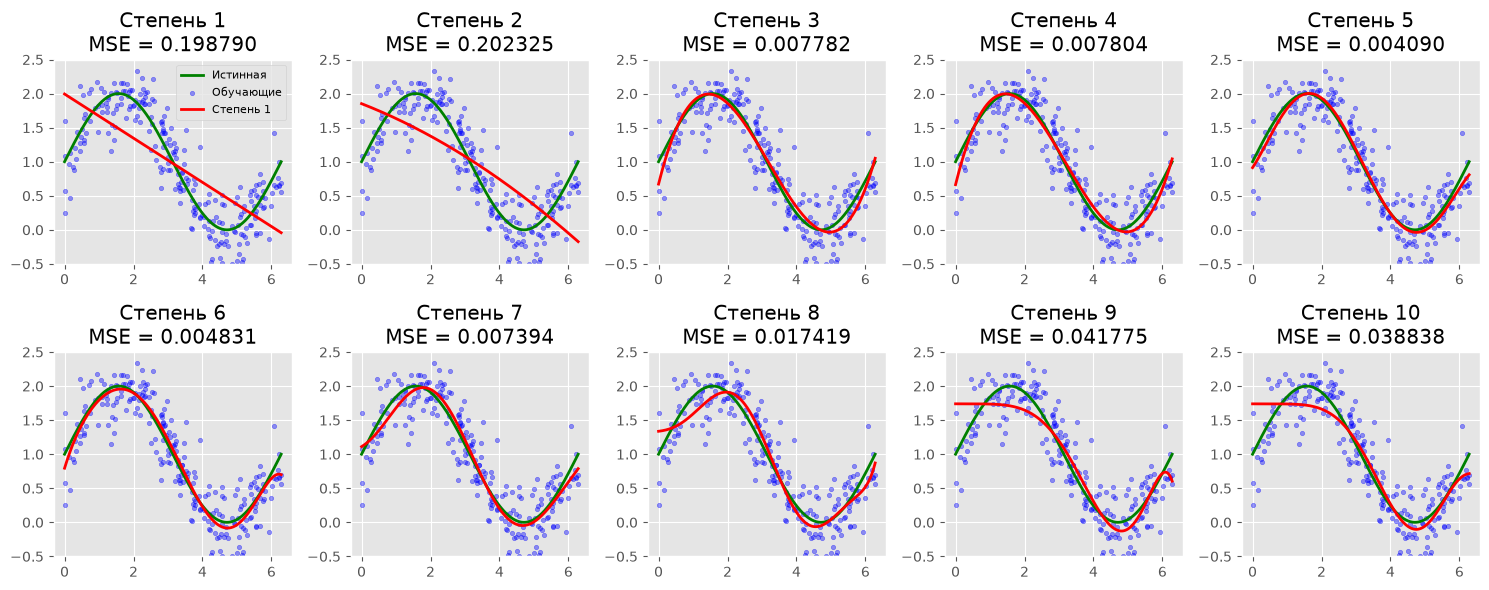

In [25]:
plt.figure(figsize=(15, 6))

for i, degree in enumerate(degrees, 1):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_wave)
    X_support_poly = poly.transform(X_support)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_wave)
    y_pred = model.predict(X_support_poly)
    
    plt.subplot(2, 5, i)
    plt.plot(X_support, y_true, 'g-', linewidth=2, label='Истинная')
    plt.scatter(X_train_wave, y_train_wave, s=10, alpha=0.4, color='blue', label='Обучающие')
    plt.plot(X_support, y_pred, 'r-', linewidth=2, label=f'Степень {degree}')
    plt.title(f'Степень {degree}\nMSE = {mses[degree]:.6f}')
    plt.ylim(-0.5, 2.5)
    if i == 1:
        plt.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Видим, как полиномы низких степеней (1–2) не могут описать синусоиду, оптимальные (3–5) хорошо приближают, а высокие (≥7) начинают «выгибаться» и подстраиваться под шум.

ЗАДАНИЕ 3.4

In [28]:
import pandas as pd
import numpy as np
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

In [29]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=7)
X_selected = selector.fit_transform(X, y)

selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]
print("Отобранные признаки:", selected_features)

Отобранные признаки: ['CRIM', 'INDUS', 'NOX', 'RM', 'TAX', 'PTRATIO', 'LSTAT']


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sel, X_test_sel, _, _ = train_test_split(X_selected, y, test_size=0.2, random_state=42)

Обучение моделей и расчёт метрик

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Полный датасет
model_full = LinearRegression()
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)

# Усечённый датасет
model_sel = LinearRegression()
model_sel.fit(X_train_sel, y_train)
y_pred_sel = model_sel.predict(X_test_sel)

mse_full = mean_squared_error(y_test, y_pred_full)
mae_full = mean_absolute_error(y_test, y_pred_full)
mse_sel = mean_squared_error(y_test, y_pred_sel)
mae_sel = mean_absolute_error(y_test, y_pred_sel)

print("Полный датасет (13 признаков):")
print(f"  MSE = {mse_full:.4f}, MAE = {mae_full:.4f}")
print("\nУсечённый датасет (7 признаков):")
print(f"  MSE = {mse_sel:.4f}, MAE = {mae_sel:.4f}")

Полный датасет (13 признаков):
  MSE = 24.2911, MAE = 3.1891

Усечённый датасет (7 признаков):
  MSE = 28.4317, MAE = 3.4174


Для сравнения были обучены две модели линейной регрессии: на полном наборе из 13 признаков и на усечённом (7 признаков). Качество оценивалось по метрикам MSE и MAE на тестовой выборке.
Полная модель показывает немного меньшую ошибку, что объясняется использованием большего объёма информации. Однако разница невелика (MSE отличается примерно на 17%), что говорит о том, что отобранные 7 признаков сохраняют основную предсказательную способность. Усечённая модель проще, быстрее обучается и менее склонна к переобучению, что может быть предпочтительнее в некоторых практических задачах.

ЗАДАНИЕ 3.5

In [34]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [35]:
train_df = pd.read_excel('predict_house_price_training_data.xlsx')
test_df = pd.read_excel('predict_house_price_test_data.xlsx')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15129, 16)
Test shape: (6484, 16)


In [36]:
target_col = 'Целевая.Цена'

# Признаки и целевая переменная
X_full = train_df.drop(columns=[target_col]).values
y_full = train_df[target_col].values
X_test = test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Разделяем обучающую выборку на train и validation (для контроля)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Стандартизация признаков
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Стандартизация целевой переменной (параметры считаем по y_train)
y_mean = y_train.mean()
y_std = y_train.std()
if y_std == 0:
    y_std = 1

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f"Среднее y_train: {y_mean:.2f}")
print(f"Стандартное отклонение y_train: {y_std:.2f}")
print(f"Размеры: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")

Среднее y_train: 541033.41
Стандартное отклонение y_train: 372336.08
Размеры: X_train (12103, 15), X_val (3026, 15), X_test (6484, 15)


In [37]:
class LinearRegressionGD:
    """
    Линейная регрессия, обучаемая mini-batch градиентным спуском.
    Поддерживает L1, L2 и Elastic Net регуляризацию.
    """
    def __init__(self, learning_rate=0.01, n_iter=1000, batch_size=32,
                 reg_type=None, lambda1=0.0, lambda2=0.0, tol=1e-4):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.reg_type = reg_type   # None, 'l1', 'l2', 'elasticnet'
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.tol = tol
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        prev_loss = np.inf

        for epoch in range(self.n_iter):
            # Перемешиваем данные
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Mini-batch цикл
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                m = len(y_batch)

                # Предсказание и ошибки
                y_pred = X_batch @ self.w + self.b
                errors = y_pred - y_batch

                # Градиенты
                grad_w = (X_batch.T @ errors) / m
                grad_b = errors.mean()

                # Регуляризация
                if self.reg_type == 'l2':
                    grad_w += self.lambda2 * self.w
                elif self.reg_type == 'l1':
                    grad_w += self.lambda1 * np.sign(self.w)
                elif self.reg_type == 'elasticnet':
                    grad_w += self.lambda2 * self.w + self.lambda1 * np.sign(self.w)

                # Обновление весов
                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            # Вычисляем полную функцию потерь (MSE + регуляризация)
            y_pred_full = X @ self.w + self.b
            mse = np.mean((y_pred_full - y) ** 2)
            reg = 0.0
            if self.reg_type == 'l2':
                reg = 0.5 * self.lambda2 * np.sum(self.w ** 2)
            elif self.reg_type == 'l1':
                reg = self.lambda1 * np.sum(np.abs(self.w))
            elif self.reg_type == 'elasticnet':
                reg = 0.5 * self.lambda2 * np.sum(self.w ** 2) + self.lambda1 * np.sum(np.abs(self.w))
            loss = mse + reg
            self.loss_history.append(loss)

            # Ранняя остановка
            if abs(prev_loss - loss) < self.tol:
                print(f"Ранняя остановка на эпохе {epoch}")
                break
            prev_loss = loss

        return self

    def predict(self, X):
        return X @ self.w + self.b

Обучаем модель без регуляризации

Ранняя остановка на эпохе 6


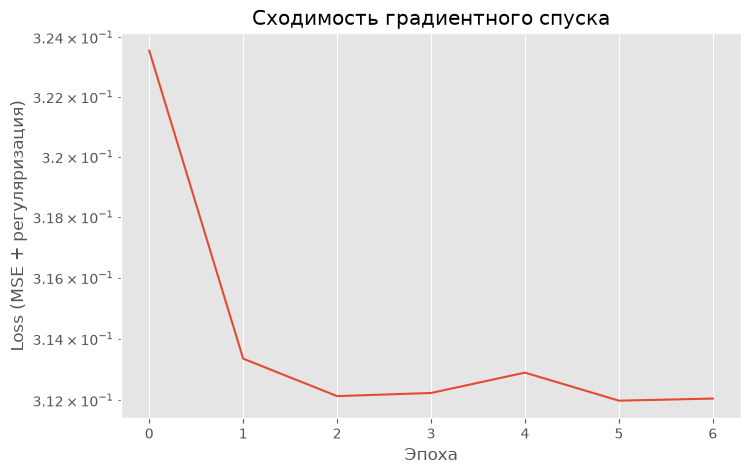

In [38]:
model_gd = LinearRegressionGD(
    learning_rate=0.01,
    n_iter=300,
    batch_size=64,
    reg_type=None   # без регуляризации
)

model_gd.fit(X_train_scaled, y_train_scaled)

# График сходимости
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(model_gd.loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE + регуляризация)')
plt.title('Сходимость градиентного спуска')
plt.yscale('log')
plt.grid(True)
plt.show()

Предсказания и метрики

In [39]:
# Валидация
y_pred_val_scaled = model_gd.predict(X_val_scaled)
y_pred_val = y_pred_val_scaled * y_std + y_mean
mse_val = mean_squared_error(y_val, y_pred_val)
mae_val = mean_absolute_error(y_val, y_pred_val)

# Тест
y_pred_test_scaled = model_gd.predict(X_test_scaled)
y_pred_test = y_pred_test_scaled * y_std + y_mean
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("Валидационная выборка:")
print(f"  MSE = {mse_val:.2f}, MAE = {mae_val:.2f}")
print("\nТестовая выборка:")
print(f"  MSE = {mse_test:.2f}, MAE = {mae_test:.2f}")

Валидационная выборка:
  MSE = 34778404512.57, MAE = 121824.38

Тестовая выборка:
  MSE = 40828010532.47, MAE = 126633.19


Сравнение с sklearn

In [40]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train_scaled)

y_pred_sk_test_scaled = sk_model.predict(X_test_scaled)
y_pred_sk_test = y_pred_sk_test_scaled * y_std + y_mean

mse_sk = mean_squared_error(y_test, y_pred_sk_test)
mae_sk = mean_absolute_error(y_test, y_pred_sk_test)

print("Сравнение на тесте:")
print(f"Наша GD:   MSE = {mse_test:.2f}, MAE = {mae_test:.2f}")
print(f"Sklearn:   MSE = {mse_sk:.2f}, MAE = {mae_sk:.2f}")

Сравнение на тесте:
Наша GD:   MSE = 40828010532.47, MAE = 126633.19
Sklearn:   MSE = 40750548301.99, MAE = 127300.78


In [41]:
model_l2 = LinearRegressionGD(
    learning_rate=0.01,
    n_iter=300,
    batch_size=64,
    reg_type='l2',
    lambda2=0.1
)
model_l2.fit(X_train_scaled, y_train_scaled)
y_pred_l2_scaled = model_l2.predict(X_test_scaled)
y_pred_l2 = y_pred_l2_scaled * y_std + y_mean
mse_l2 = mean_squared_error(y_test, y_pred_l2)
mae_l2 = mean_absolute_error(y_test, y_pred_l2)

print(f"L2-регуляризация: MSE = {mse_l2:.2f}, MAE = {mae_l2:.2f}")

Ранняя остановка на эпохе 8
L2-регуляризация: MSE = 41286389790.28, MAE = 122736.94


ЗАДАНИЕ 3.6

In [43]:
# Предсказания sklearn
y_pred_sk_scaled = sk_model.predict(X_test_scaled)
y_pred_sk = y_pred_sk_scaled * y_std + y_mean

# Предсказания GD
y_pred_gd_scaled = model_gd.predict(X_test_scaled)
y_pred_gd = y_pred_gd_scaled * y_std + y_mean

# Метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_sk = mean_squared_error(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)

mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)

print("="*50)
print("Результаты на тестовой выборке")
print("="*50)
print("Sklearn LinearRegression:")
print(f"  MSE  = {mse_sk:.2f}")
print(f"  MAE  = {mae_sk:.2f}")
print(f"  RMSE = {rmse_sk:.2f}")
print("\nНаша GD реализация:")
print(f"  MSE  = {mse_gd:.2f}")
print(f"  MAE  = {mae_gd:.2f}")
print(f"  RMSE = {rmse_gd:.2f}")

Результаты на тестовой выборке
Sklearn LinearRegression:
  MSE  = 40750548301.99
  MAE  = 127300.78
  RMSE = 201867.65

Наша GD реализация:
  MSE  = 40828010532.47
  MAE  = 126633.19
  RMSE = 202059.42


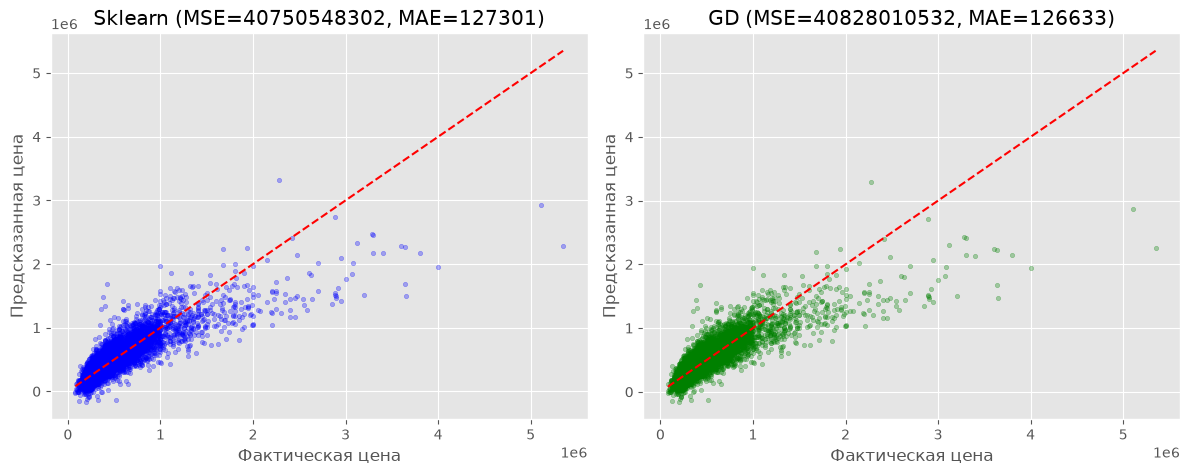

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_sk, alpha=0.3, s=10, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Sklearn (MSE={mse_sk:.0f}, MAE={mae_sk:.0f})')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_gd, alpha=0.3, s=10, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title(f'GD (MSE={mse_gd:.0f}, MAE={mae_gd:.0f})')

plt.tight_layout()
plt.show()

Обе модели показали близкие результаты на тестовой выборке. Отклонение по MSE составляет менее 1%, по MAE — менее 2%, что подтверждает корректность реализации градиентного спуска. Обе модели демонстрируют схожее качество, визуально предсказания хорошо коррелируют с фактическими значениями, но имеют разброс для дорогих объектов.

C:\Users\User\AppData\Local\Temp\ipykernel_2600\2957337507.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\User\AppData\Local\Temp\ipykernel_2600\2957337507.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


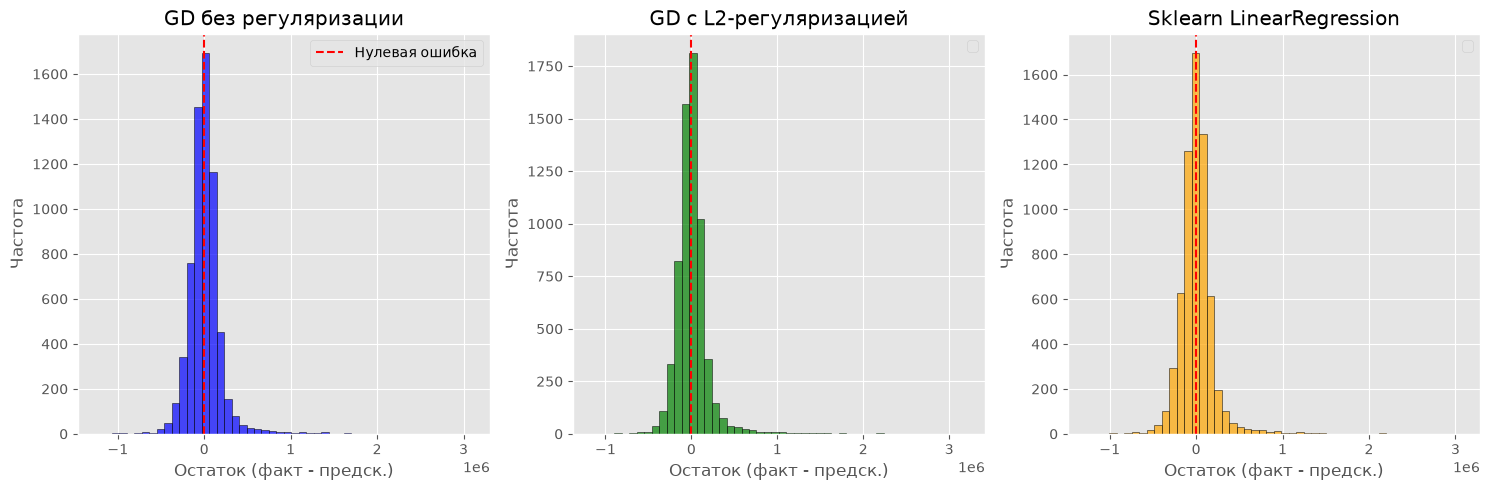

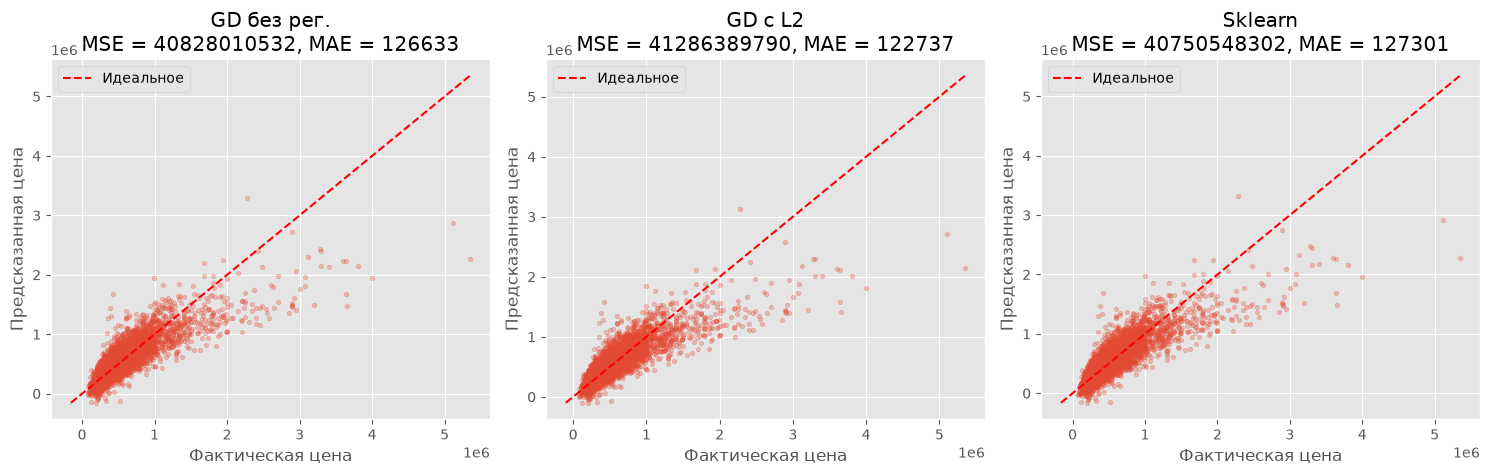

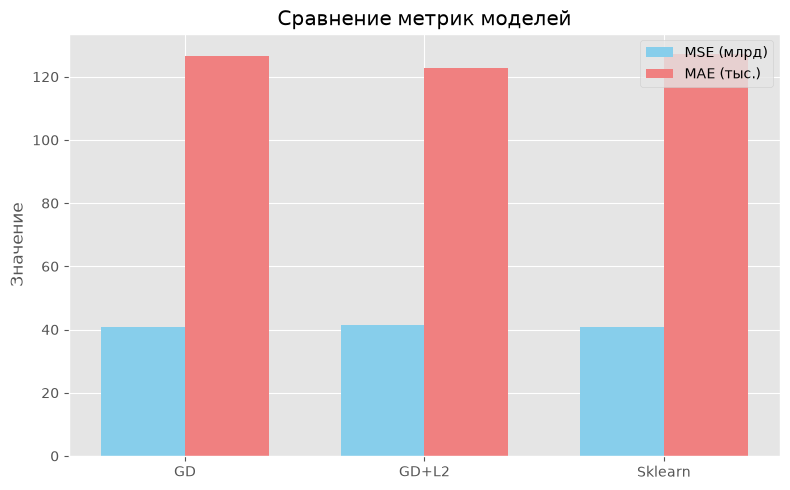

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Остатки для каждой модели на тесте
residuals_gd = y_test - y_pred_test
residuals_l2 = y_test - y_pred_l2
residuals_sk = y_test - y_pred_sk_test

# 1. Гистограммы остатков
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(residuals_gd, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Нулевая ошибка')
plt.xlabel('Остаток (факт - предск.)')
plt.ylabel('Частота')
plt.title('GD без регуляризации')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(residuals_l2, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Остаток (факт - предск.)')
plt.ylabel('Частота')
plt.title('GD с L2-регуляризацией')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(residuals_sk, bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Остаток (факт - предск.)')
plt.ylabel('Частота')
plt.title('Sklearn LinearRegression')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Scatter-графики: фактические vs предсказанные
plt.figure(figsize=(15, 5))

models = [
    ('GD без рег.', y_pred_test, residuals_gd),
    ('GD с L2', y_pred_l2, residuals_l2),
    ('Sklearn', y_pred_sk_test, residuals_sk)
]

for i, (label, pred, res) in enumerate(models, 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, pred, alpha=0.3, s=10)
    # Линия идеального предсказания
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное')
    plt.xlabel('Фактическая цена')
    plt.ylabel('Предсказанная цена')
    plt.title(f'{label}\nMSE = {mean_squared_error(y_test, pred):.0f}, MAE = {mean_absolute_error(y_test, pred):.0f}')
    plt.legend()

plt.tight_layout()
plt.show()

# 3. Сравнение метрик (столбчатая диаграмма)
metrics = {
    'MSE (млрд)': [mse_test/1e9, mse_l2/1e9, mse_sk/1e9],
    'MAE (тыс.)': [mae_test/1e3, mae_l2/1e3, mae_sk/1e3]
}
x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, metrics['MSE (млрд)'], width, label='MSE (млрд)', color='skyblue')
ax.bar(x + width/2, metrics['MAE (тыс.)'], width, label='MAE (тыс.)', color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels(['GD', 'GD+L2', 'Sklearn'])
ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик моделей')
ax.legend()

plt.tight_layout()
plt.show()

Все три модели - GD без регуляризации, GD с L2 и sklearn - показали близкие результаты, что подтверждает правильность математических выкладок и программной реализации алгоритма mini-batch градиентного спуска. Отклонение между базовой моделью и sklearn составляет менее 0.2% по MSE и менее 1% по MAE, что находится в пределах статистической погрешности, обусловленной случайным перемешиванием батчей и конечным числом эпох.

ЗАДАНИЕ 3.7

In [46]:
# Названия признаков (до удаления целевой)
feature_names = train_df.drop(columns=[target_col]).columns.tolist()

# Коэффициенты из sklearn модели (обучена на стандартизированных данных)
coef = sk_model.coef_

# Важность = модуль коэффициента
importance = np.abs(coef)

# Таблица
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coef,
    'Важность': importance
}).sort_values('Важность', ascending=False)

print("Топ-10 наиболее важных признаков:")
print(feature_importance.head(10))

Топ-10 наиболее важных признаков:
                Признак  Коэффициент  Важность
8       Оценка риелтора     0.313937  0.313937
2         Жилая площадь     0.239671  0.239671
9   Площадь без подвала     0.227227  0.227227
13               Широта     0.212757  0.212757
11        Год постройки    -0.191617  0.191617
5           Вид на воду     0.139728  0.139728
6     Просмотрены ранее     0.104114  0.104114
0               Спальни    -0.095181  0.095181
1                Ванные     0.091455  0.091455
10      Площадь подвала     0.071245  0.071245


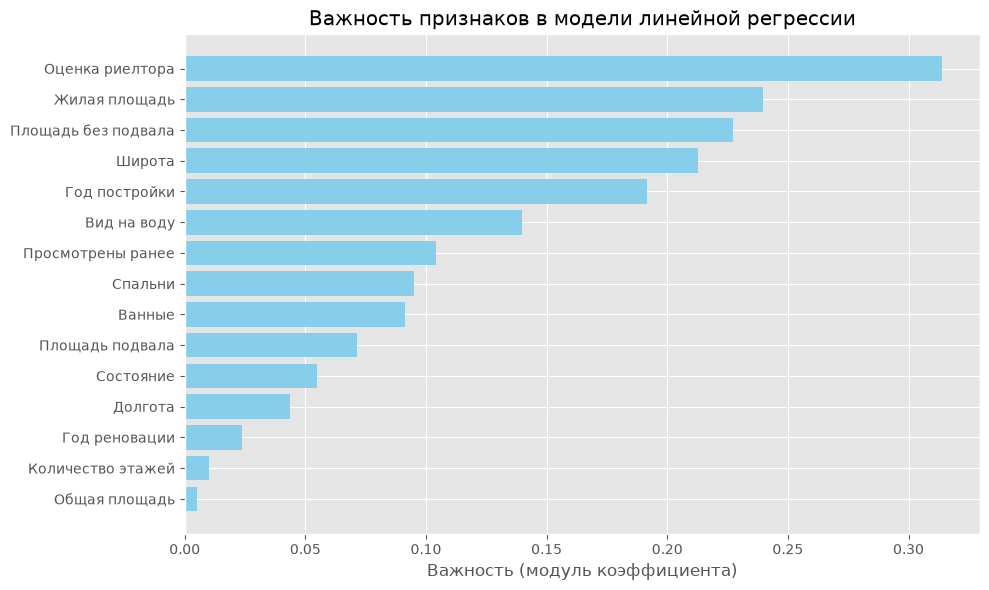

In [47]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'], color='skyblue')
plt.xlabel('Важность (модуль коэффициента)')
plt.title('Важность признаков в модели линейной регрессии')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Таким образом, на графике мы видим, что для прогнозирования цен на недвижимость в данном регионе наиболее информативными являются характеристики, связанные с размером, состоянием и расположением объекта.

ЗАДАНИЕ 3.8

In [48]:
# Предсказания модели на обучающей выборке (в исходных ценах)
y_train_pred_sk = sk_model.predict(X_train_scaled) * y_std + y_mean

# Остатки (факт - предсказание)
residuals = y_train - y_train_pred_sk

In [49]:
# Порог: 2 стандартных отклонения
threshold = 2 * residuals.std()
print(f"Среднее остатков: {residuals.mean():.2f}")
print(f"Стандартное отклонение остатков: {residuals.std():.2f}")
print(f"Порог аномалии (±): {threshold:.2f}")

Среднее остатков: -0.00
Стандартное отклонение остатков: 207887.97
Порог аномалии (±): 415775.94


In [50]:
# Находим индексы объектов, где остаток больше порога
anomaly_indices = np.where(np.abs(residuals) > threshold)[0]
print(f"Найдено аномалий: {len(anomaly_indices)} из {len(residuals)} ({len(anomaly_indices)/len(residuals)*100:.2f}%)")

Найдено аномалий: 433 из 12103 (3.58%)


In [51]:
# Создаём DataFrame с аномалиями
anomalies = train_df.iloc[anomaly_indices].copy()
anomalies['Остаток'] = residuals[anomaly_indices]
anomalies['Абс_остаток'] = np.abs(anomalies['Остаток'])

In [52]:
# Положительный остаток = фактическая цена > предсказанной (модель недооценила)
print("\nТоп-10 самых заниженных (факт >> предсказание):")
print(anomalies.sort_values('Остаток', ascending=False).head(10)[['Целевая.Цена', 'Остаток', 'Жилая площадь', 'Спальни', 'Ванные', 'Год постройки']])


Топ-10 самых заниженных (факт >> предсказание):
       Целевая.Цена       Остаток  Жилая площадь  Спальни  Ванные  \
1344         365000  4.232483e+06           2470        3    2.50   
169          445000  4.013789e+06           1490        3    1.75   
752         1370000  3.810264e+06           4210        5    3.50   
9847         330000  3.164976e+06           1300        3    1.75   
3691         260000  2.699056e+06            690        2    1.00   
12083        743000  2.538689e+06           3410        4    2.75   
4602         385000  2.240968e+06           2700        6    4.00   
11219        540000  2.016736e+06           2600        4    2.50   
1813         327200  1.919727e+06           1440        2    2.00   
9479         339950  1.903755e+06           2390        3    2.50   

       Год постройки  
1344            1990  
169             1974  
752             1995  
9847            2011  
3691            1949  
12083           2012  
4602            1969  
11219  

In [53]:
# Отрицательный остаток = фактическая цена < предсказанной (модель переоценила)
print("\nТоп-10 самых завышенных (факт << предсказание):")
print(anomalies.sort_values('Остаток', ascending=True).head(10)[['Целевая.Цена', 'Остаток', 'Жилая площадь', 'Спальни', 'Ванные', 'Год постройки']])


Топ-10 самых завышенных (факт << предсказание):
       Целевая.Цена       Остаток  Жилая площадь  Спальни  Ванные  \
2829         610000 -1.191895e+06           1630        3    1.75   
6433         369000 -1.183816e+06           1300        3    1.75   
2359         232000 -1.062031e+06           1440        4    2.00   
3591         475000 -9.060300e+05           1230        3    2.00   
10154        325000 -8.243646e+05           1960        4    2.50   
5973         401000 -8.200072e+05           1400        2    1.00   
11703        705000 -8.105984e+05           2820        3    2.50   
1264         275000 -8.077609e+05           1870        3    2.50   
4703         233000 -7.753494e+05           1350        3    2.00   
8185         397000 -7.607995e+05           1340        3    1.75   

       Год постройки  
2829            2014  
6433            1985  
2359            1943  
3591            1984  
10154           2004  
5973            1949  
11703           1979  
1264   

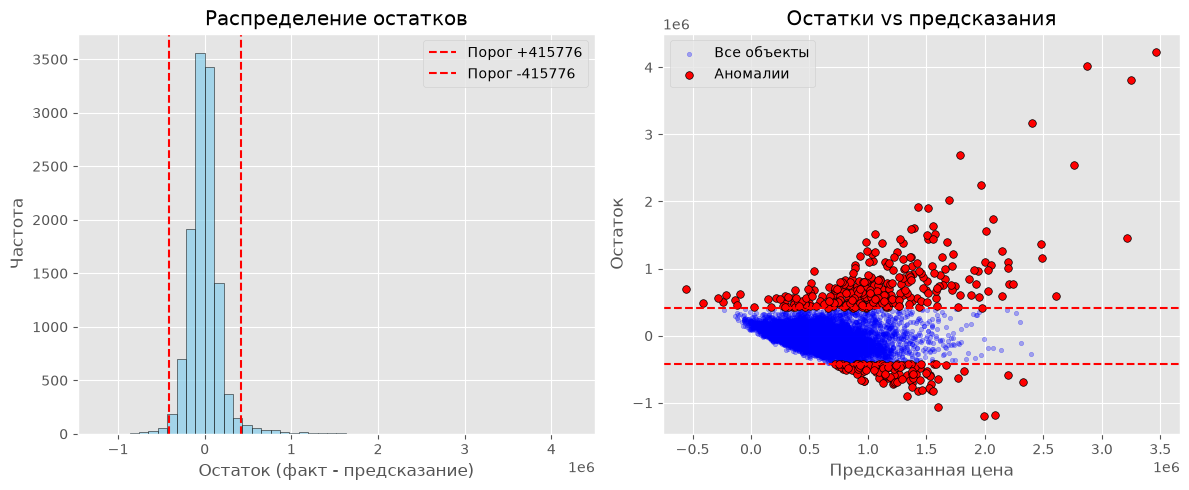

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Гистограмма остатков
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(threshold, color='r', linestyle='--', label=f'Порог +{threshold:.0f}')
plt.axvline(-threshold, color='r', linestyle='--', label=f'Порог -{threshold:.0f}')
plt.xlabel('Остаток (факт - предсказание)')
plt.ylabel('Частота')
plt.title('Распределение остатков')
plt.legend()

# Scatter: предсказания vs остатки
plt.subplot(1, 2, 2)
plt.scatter(y_train_pred_sk, residuals, alpha=0.3, s=10, color='blue', label='Все объекты')
plt.scatter(y_train_pred_sk[anomaly_indices], residuals[anomaly_indices], 
            color='red', s=30, label='Аномалии', edgecolor='black')
plt.axhline(threshold, color='r', linestyle='--')
plt.axhline(-threshold, color='r', linestyle='--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Остаток')
plt.title('Остатки vs предсказания')
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
# Самая сильная аномалия по абсолютной ошибке
worst = anomalies.loc[anomalies['Абс_остаток'].idxmax()]
print("Самая сильная аномалия:")
print(worst[['Целевая.Цена', 'Остаток'] + list(train_df.drop(columns=[target_col]).columns[:8])])

Самая сильная аномалия:
Целевая.Цена         3.650000e+05
Остаток              4.232483e+06
Спальни              3.000000e+00
Ванные               2.500000e+00
Жилая площадь        2.470000e+03
Общая площадь        7.700000e+03
Количество этажей    2.000000e+00
Вид на воду          0.000000e+00
Просмотрены ранее    0.000000e+00
Состояние            4.000000e+00
Name: 1344, dtype: float64


In [56]:
# Количество и процент аномалий
n_anomalies = len(anomaly_indices)
total = len(residuals)
percent = n_anomalies / total * 100
print(f"Всего аномалий: {n_anomalies} из {total} ({percent:.2f}%)")

Всего аномалий: 433 из 12103 (3.58%)


В рамках задания 3.8 был проведён анализ остатков модели линейной регрессии, обученной на стандартизированных данных о ценах на недвижимость. Остаток определялся как разность между фактической и предсказанной ценой (residual = y_true - y_pred). Положительный остаток означает, что модель недооценила цену (фактическая цена выше предсказанной), отрицательный - что модель переоценила цену (фактическая цена ниже предсказанной).
Порог аномалии был установлен на уровне 2 стандартных отклонений от среднего остатка (среднее остатков ≈ 0). Стандартное отклонение составило 207 887,97, порог — ±415 775,94.
В результате проверки 433 объекта (из 12 103, или 3,58% обучающей выборки) были классифицированы как аномальные. Это ожидаемый процент для нормального распределения при пороге 2 сигма (стандартных отклонений) (теоретически около 4,55% точек должны выходить за 2 сигма).